# Detection by Shadow — Notebook Baseline

This notebook builds a **first machine learning baseline** for the Kaggle challenge.

The idea is:

1. Read the training images and JSON labels  
2. Extract **shadow geometry features** from each image with OpenCV  
3. Convert the original box labels into easier training targets:
   - `side`
   - `y_bottom`
   - `height`
   - `width`
   - `x_offset`
4. Train small models on those targets
5. Reconstruct the final:
   - `xmin`
   - `ymin`
   - `xmax`
   - `ymax`
6. Create a `submission.csv`

This is a **structured baseline**:
- OpenCV handles the shadow features
- classical ML handles the predictions
- then we reconstruct the final bounding box

## 1. Imports

In [1]:
import os
import json
import glob
import math
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split

## 2. Configuration

Adjust these paths if needed.  
On Kaggle, they should normally point to the competition dataset.

In [2]:
warnings.filterwarnings("ignore")

TRAIN_DIR = "C:/Users/pa3kg/OneDrive/Документи/Brabant_Hack2026/data/train_data/train_data"
TEST_DIR = "C:/Users/pa3kg/OneDrive/Документи/Brabant_Hack2026/data/test_data/test_data"
SAMPLE_SUBMISSION_PATH = "/data/submission_example.csv"

IMAGE_EXTENSIONS = [".png", ".jpg", ".jpeg"]
RANDOM_STATE = 42

In [3]:
def get_image_paths(folder):
    return sorted(glob.glob(os.path.join(folder, "*.png")))

print("Train images:", len(get_image_paths(TRAIN_DIR)))
print("Test images:", len(get_image_paths(TEST_DIR)))

print("First few train files:")
for p in get_image_paths(TRAIN_DIR)[:5]:
    print(os.path.basename(p))

Train images: 1692
Test images: 414
First few train files:
image_0.png
image_10.png
image_100.png
image_1000.png
image_1001.png


In [4]:
for img_path in get_image_paths(TRAIN_DIR)[:5]:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    json_path = os.path.join(TRAIN_DIR, f"{stem}.json")
    print(stem, "->", os.path.exists(json_path))

image_0 -> True
image_10 -> True
image_100 -> True
image_1000 -> True
image_1001 -> True


## 3. Small helper functions

In [5]:
def load_image(path: str) -> np.ndarray:
    data = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return img

def load_json(path: str) -> dict:
    with open(path, "r") as f:
        return json.load(f)

def get_image_paths(folder: str):
    paths = []
    for ext in IMAGE_EXTENSIONS:
        paths.extend(glob.glob(os.path.join(folder, f"*{ext}")))
    return sorted(paths)

def safe_div(a, b, default=0.0):
    return a / b if b != 0 else default

## 4. Turn the original JSON into more useful targets

The competition wants:

- `xmin`
- `ymin`
- `xmax`
- `ymax`

But during training it is often easier to learn:

- `side` → left or right of frame
- `y_bottom` → bottom of the box
- `height`
- `width`
- `x_offset` → how far outside the frame the person is

Then later we reconstruct the final box.

In [6]:
def extract_targets_from_json(label_data: dict, image_width: int):
    bbox = label_data["bbox"]

    xmin = float(bbox["top_left"][0])
    ymin = float(bbox["top_left"][1])
    xmax = float(bbox["top_right"][0])
    ymax = float(bbox["bottom_left"][1])

    width = xmax - xmin
    height = ymax - ymin
    y_bottom = ymax

    # side: 0 = left, 1 = right
    if xmax <= 0:
        side = 0
        x_offset = -xmax
    elif xmin >= image_width:
        side = 1
        x_offset = xmin - image_width
    else:
        center_x = (xmin + xmax) / 2.0
        side = 0 if center_x < image_width / 2 else 1
        x_offset = 0.0

    direction = int(label_data.get("walking_into_frame_bool", -1))

    return {
        "xmin": xmin,
        "ymin": ymin,
        "xmax": xmax,
        "ymax": ymax,
        "width": width,
        "height": height,
        "y_bottom": y_bottom,
        "side": side,
        "x_offset": x_offset,
        "direction": direction,
    }

## 5. Shadow extraction

This is a simple first version:

- convert to grayscale
- blur
- threshold dark pixels
- clean with morphology

Because the dataset is synthetic, a simple mask can already work surprisingly well.

In [7]:
def find_shadow_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    best = None
    best_score = 0

    for c in contours:
        area = cv2.contourArea(c)
        if area < 200:  # remove tiny noise
            continue

        x, y, w, h = cv2.boundingRect(c)
        aspect_ratio = max(w, h) / (min(w, h) + 1e-5)

        # shadow should be elongated
        if aspect_ratio > 3:
            score = area * aspect_ratio
            if score > best_score:
                best = c
                best_score = score

    return best

def compute_shadow_mask(img):
    h, w = img.shape[:2]

    # Keep only the lower part where the road and shadow are likely to be
    y_start = int(h * 0.55)
    roi = img[y_start:, :]

    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (7, 7), 0)

    # Simple dark-region threshold
    _, mask = cv2.threshold(gray_blur, 85, 255, cv2.THRESH_BINARY_INV)

    # Clean up
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return roi, gray_blur, mask, y_start

def largest_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    best = None
    best_score = -1
    h, w = mask.shape[:2]

    for c in contours:
        area = cv2.contourArea(c)
        if area < 50 or area > 4000:
            continue

        x, y, bw, bh = cv2.boundingRect(c)
        aspect = bw / (bh + 1e-6)
        cy = y + bh / 2

        # Prefer elongated blobs
        if aspect < 1.3:
            continue

        # Prefer blobs lower in the ROI
        score = area * (1 + cy / h)

        if score > best_score:
            best = c
            best_score = score

    return best

## 6. PCA line fit on the shadow

This tries to find the **main axis** of the shadow.

That gives us:
- a center point
- a main direction
- an approximate angle

In [8]:
def fit_pca_features(contour: np.ndarray):
    pts = contour.reshape(-1, 2).astype(np.float32)

    if len(pts) < 5:
        return {
            "pca_cx": 0.0,
            "pca_cy": 0.0,
            "major_dx": 1.0,
            "major_dy": 0.0,
            "major_len": 0.0,
            "minor_len": 0.0,
            "angle_deg": 0.0,
        }

    mean, eigenvectors, eigenvalues = cv2.PCACompute2(pts, mean=np.empty((0)))
    cx, cy = mean[0]

    major = eigenvectors[0]
    major_dx, major_dy = float(major[0]), float(major[1])

    major_len = float(np.sqrt(eigenvalues[0][0])) if eigenvalues.shape[0] > 0 else 0.0
    minor_len = float(np.sqrt(eigenvalues[1][0])) if eigenvalues.shape[0] > 1 else 0.0
    angle_deg = float(np.degrees(np.arctan2(major_dy, major_dx)))

    return {
        "pca_cx": float(cx),
        "pca_cy": float(cy),
        "major_dx": major_dx,
        "major_dy": major_dy,
        "major_len": major_len,
        "minor_len": minor_len,
        "angle_deg": angle_deg,
    }

## 7. Border-intersection features

We also compute where the shadow axis would hit the image borders.  
These can be surprisingly useful features for predicting the off-screen person.

In [9]:
def line_border_intersections(cx, cy, dx, dy, width, height):
    result = {
        "y_at_left": -9999.0,
        "y_at_right": -9999.0,
        "x_at_top": -9999.0,
        "x_at_bottom": -9999.0,
    }

    if abs(dx) > 1e-6:
        t_left = (0 - cx) / dx
        t_right = ((width - 1) - cx) / dx
        result["y_at_left"] = cy + t_left * dy
        result["y_at_right"] = cy + t_right * dy

    if abs(dy) > 1e-6:
        t_top = (0 - cy) / dy
        t_bottom = ((height - 1) - cy) / dy
        result["x_at_top"] = cx + t_top * dx
        result["x_at_bottom"] = cx + t_bottom * dx

    return result

## 8. Full feature extraction from one image

This collects:

- contour features
- bounding box of the shadow
- extremal points
- grayscale stats
- PCA features
- border-intersection features
- normalized variants

In [10]:
def get_pca_tip_points(contour, pca_cx, pca_cy, dx, dy):
    pts = contour.reshape(-1, 2).astype(np.float32)
    center = np.array([pca_cx, pca_cy], dtype=np.float32)
    direction = np.array([dx, dy], dtype=np.float32)

    projections = (pts - center) @ direction
    far_idx = np.argmax(projections)
    near_idx = np.argmin(projections)

    far_pt = pts[far_idx]
    near_pt = pts[near_idx]

    return far_pt, near_pt


def extract_shadow_features(img: np.ndarray):
    h, w = img.shape[:2]
    roi, gray_blur, mask, y_start = compute_shadow_mask(img)
    roi_h, roi_w = roi.shape[:2]
    contour = largest_contour(mask)

    features = {
        "img_w": float(w),
        "img_h": float(h),
        "roi_w": float(roi_w),
        "roi_h": float(roi_h),
        "roi_y_start": float(y_start),
        "shadow_found": 0.0,
        "mask_ratio": float(np.count_nonzero(mask)) / float(mask.size),

        "contour_area": 0.0,
        "contour_perimeter": 0.0,
        "bbox_x": 0.0,
        "bbox_y": 0.0,
        "bbox_w": 0.0,
        "bbox_h": 0.0,
        "bbox_aspect": 0.0,
        "bbox_cx": 0.0,
        "bbox_cy": 0.0,

        "leftmost_x": 0.0,
        "leftmost_y": 0.0,
        "rightmost_x": 0.0,
        "rightmost_y": 0.0,
        "topmost_x": 0.0,
        "topmost_y": 0.0,
        "bottommost_x": 0.0,
        "bottommost_y": 0.0,

        "dist_left": float(roi_w),
        "dist_right": float(roi_w),
        "touches_left": 0.0,
        "touches_right": 0.0,

        "mean_gray_shadow": 0.0,
        "std_gray_shadow": 0.0,

        "pca_cx": 0.0,
        "pca_cy": 0.0,
        "major_dx": 1.0,
        "major_dy": 0.0,
        "major_len": 0.0,
        "minor_len": 0.0,
        "angle_deg": 0.0,

        "y_at_left": -9999.0,
        "y_at_right": -9999.0,
        "x_at_top": -9999.0,
        "x_at_bottom": -9999.0,

        # new shape features
        "solidity": 0.0,
        "extent": 0.0,
        "rot_w": 0.0,
        "rot_h": 0.0,
        "rot_aspect": 0.0,
        "rot_angle": 0.0,

        # new PCA tip features
        "far_x": 0.0,
        "far_y": 0.0,
        "near_x": 0.0,
        "near_y": 0.0,

        # side hints
        "shadow_side_hint": 0.0,
        "edge_distance_ratio": 0.0,
    }

    if contour is None or len(contour) < 5:
        return features

    features["shadow_found"] = 1.0

    area = cv2.contourArea(contour)
    peri = cv2.arcLength(contour, True)
    x, y, bw, bh = cv2.boundingRect(contour)

    pts = contour.reshape(-1, 2)
    leftmost = pts[np.argmin(pts[:, 0])]
    rightmost = pts[np.argmax(pts[:, 0])]
    topmost = pts[np.argmin(pts[:, 1])]
    bottommost = pts[np.argmax(pts[:, 1])]

    shadow_pixels = gray_blur[mask > 0]
    mean_gray = float(np.mean(shadow_pixels)) if len(shadow_pixels) > 0 else 0.0
    std_gray = float(np.std(shadow_pixels)) if len(shadow_pixels) > 0 else 0.0

    pca = fit_pca_features(contour)
    line_feats = line_border_intersections(
        pca["pca_cx"], pca["pca_cy"], pca["major_dx"], pca["major_dy"], roi_w, roi_h
    )

    # convex hull / solidity
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0.0

    # extent
    rect_area = bw * bh
    extent = area / rect_area if rect_area > 0 else 0.0

    # rotated rectangle
    rot_rect = cv2.minAreaRect(contour)
    (_, _), (rw, rh), rangle = rot_rect
    rot_w = float(max(rw, rh))
    rot_h = float(min(rw, rh))
    rot_aspect = rot_w / (rot_h + 1e-6)

    # pca tip points
    far_pt, near_pt = get_pca_tip_points(
        contour,
        pca["pca_cx"],
        pca["pca_cy"],
        pca["major_dx"],
        pca["major_dy"]
    )

    dist_left = float(leftmost[0])
    dist_right = float((roi_w - 1) - rightmost[0])

    features.update({
        "contour_area": float(area),
        "contour_perimeter": float(peri),

        "bbox_x": float(x),
        "bbox_y": float(y),
        "bbox_w": float(bw),
        "bbox_h": float(bh),
        "bbox_aspect": safe_div(bw, bh, 0.0),
        "bbox_cx": float(x + bw / 2.0),
        "bbox_cy": float(y + bh / 2.0),

        "leftmost_x": float(leftmost[0]),
        "leftmost_y": float(leftmost[1]),
        "rightmost_x": float(rightmost[0]),
        "rightmost_y": float(rightmost[1]),
        "topmost_x": float(topmost[0]),
        "topmost_y": float(topmost[1]),
        "bottommost_x": float(bottommost[0]),
        "bottommost_y": float(bottommost[1]),

        "dist_left": dist_left,
        "dist_right": dist_right,
        "touches_left": 1.0 if leftmost[0] <= 2 else 0.0,
        "touches_right": 1.0 if rightmost[0] >= roi_w - 3 else 0.0,

        "mean_gray_shadow": mean_gray,
        "std_gray_shadow": std_gray,

        "solidity": float(solidity),
        "extent": float(extent),
        "rot_w": rot_w,
        "rot_h": rot_h,
        "rot_aspect": float(rot_aspect),
        "rot_angle": float(rangle),

        "far_x": float(far_pt[0]),
        "far_y": float(far_pt[1]),
        "near_x": float(near_pt[0]),
        "near_y": float(near_pt[1]),

        "shadow_side_hint": 1.0 if dist_left < dist_right else 0.0,
        "edge_distance_ratio": dist_left / (dist_right + 1e-6),
    })

    features.update(pca)
    features.update(line_feats)

    normalized = {}
    for key in [
        "bbox_x", "bbox_y", "bbox_w", "bbox_h", "bbox_cx", "bbox_cy",
        "leftmost_x", "leftmost_y", "rightmost_x", "rightmost_y",
        "topmost_x", "topmost_y", "bottommost_x", "bottommost_y",
        "dist_left", "dist_right", "pca_cx", "pca_cy",
        "y_at_left", "y_at_right", "x_at_top", "x_at_bottom",
        "far_x", "far_y", "near_x", "near_y", "rot_w", "rot_h"
    ]:
        if "x" in key or "left" in key or "right" in key or key in ["rot_w"]:
            normalized[f"{key}_norm"] = features[key] / max(roi_w, 1)
        else:
            normalized[f"{key}_norm"] = features[key] / max(roi_h, 1)

    normalized["contour_area_norm"] = features["contour_area"] / float(roi_w * roi_h)
    normalized["contour_perimeter_norm"] = features["contour_perimeter"] / float(roi_w + roi_h)
    normalized["major_len_norm"] = features["major_len"] / max(roi_w, roi_h)
    normalized["minor_len_norm"] = features["minor_len"] / max(roi_w, roi_h)

    features.update(normalized)
    return features

## 9. Quick visual debug

This helps you check whether the mask and contour make sense on a sample image.

In [11]:
def show_shadow_debug(image_path):
    img = load_image(image_path)
    roi, gray_blur, mask, y_start = compute_shadow_mask(img)
    contour = largest_contour(mask)

    debug_roi = roi.copy()

    if contour is not None and len(contour) >= 5:
        cv2.drawContours(debug_roi, [contour], -1, (0, 255, 0), 2)

        pca = fit_pca_features(contour)
        cx, cy = int(pca["pca_cx"]), int(pca["pca_cy"])
        dx, dy = pca["major_dx"], pca["major_dy"]

        pt1 = (int(cx - 200 * dx), int(cy - 200 * dy))
        pt2 = (int(cx + 200 * dx), int(cy + 200 * dy))
        cv2.line(debug_roi, pt1, pt2, (255, 0, 0), 2)
        cv2.circle(debug_roi, (cx, cy), 5, (0, 0, 255), -1)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")

    axes[1].imshow(gray_blur, cmap="gray")
    axes[1].set_title("Gray ROI")

    axes[2].imshow(mask, cmap="gray")
    axes[2].set_title("Shadow Mask")

    axes[3].imshow(cv2.cvtColor(debug_roi, cv2.COLOR_BGR2RGB))
    axes[3].set_title("Chosen Contour + PCA")

    for ax in axes:
        ax.axis("off")
    plt.show()

Run this on one sample first and see whether the mask mostly captures the shadow.

Found 1692 training images


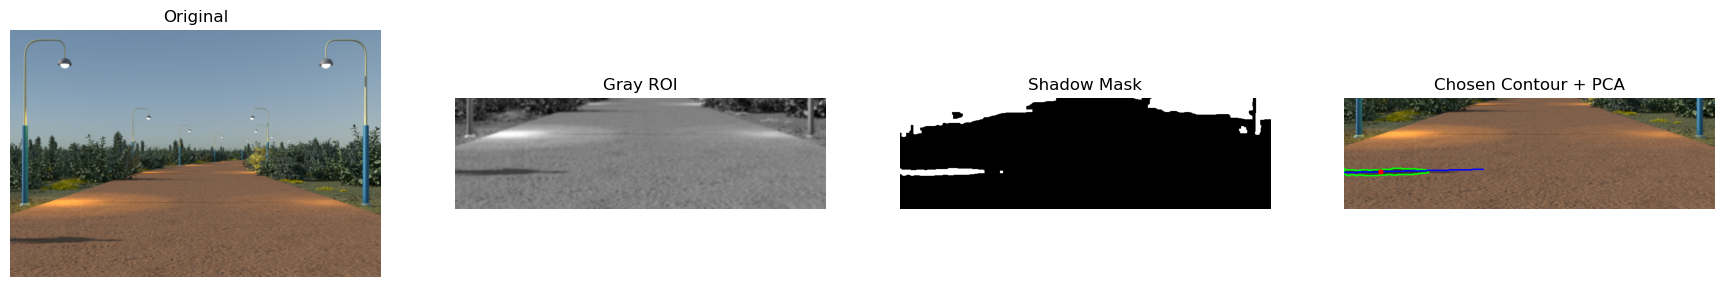

In [12]:
train_image_paths = get_image_paths(TRAIN_DIR)
print(f"Found {len(train_image_paths)} training images")

if len(train_image_paths) > 0:
    show_shadow_debug(train_image_paths[0])

## 10. Build the training DataFrame

Each row will contain:

- extracted shadow features
- transformed learning targets
- original bbox values

In [13]:
def build_train_dataframe(train_dir: str):
    rows = []
    image_paths = get_image_paths(train_dir)

    for img_path in image_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        json_path = os.path.join(train_dir, f"{stem}.json")
        if not os.path.exists(json_path):
            continue

        img = load_image(img_path)
        h, w = img.shape[:2]

        feats = extract_shadow_features(img)
        label = extract_targets_from_json(load_json(json_path), image_width=w)

        row = {"id": stem}
        row.update(feats)
        row.update(label)
        rows.append(row)

    return pd.DataFrame(rows)

train_df = build_train_dataframe(TRAIN_DIR)
print(train_df.shape)
train_df.head()

(1692, 96)


,id,img_w,img_h,roi_w,roi_h,roi_y_start,shadow_found,mask_ratio,contour_area,contour_perimeter,...,xmin,ymin,xmax,ymax,width,height,y_bottom,side,x_offset,direction
0,image_0,720.0,480.0,720.0,216.0,264.0,1.0,0.143171,1663.0,353.597979,...,-228.877144,223.618740,-110.614879,416.358789,118.262265,192.740049,416.358789,0,110.614879,1
1,image_10,720.0,480.0,720.0,216.0,264.0,1.0,0.142329,1925.0,334.083260,...,-307.385595,215.691074,-243.787758,438.103111,63.597836,222.412037,438.103111,0,243.787758,0
2,image_100,720.0,480.0,720.0,216.0,264.0,1.0,0.182157,759.5,219.012193,...,-253.668909,215.604729,-174.385954,434.196810,79.282955,218.592081,434.196810,0,174.385954,1
3,image_1000,720.0,480.0,720.0,216.0,264.0,1.0,0.461060,2220.5,494.124890,...,-234.063807,227.459578,-138.250784,379.189109,95.813023,151.729531,379.189109,0,138.250784,0
4,image_1001,720.0,480.0,720.0,216.0,264.0,1.0,0.207735,1461.0,510.769552,...,-195.748172,225.637964,-87.976198,392.705318,107.771974,167.067354,392.705318,0,87.976198,1


## 11. Build the test DataFrame

In [14]:
def build_test_dataframe(test_dir: str):
    rows = []
    image_paths = get_image_paths(test_dir)

    for img_path in image_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        img = load_image(img_path)
        feats = extract_shadow_features(img)

        row = {"id": stem}
        row.update(feats)
        rows.append(row)

    return pd.DataFrame(rows)

test_df = build_test_dataframe(TEST_DIR)
print(test_df.shape)
test_df.head()

(414, 86)


,id,img_w,img_h,roi_w,roi_h,roi_y_start,shadow_found,mask_ratio,contour_area,contour_perimeter,...,far_x_norm,far_y_norm,near_x_norm,near_y_norm,rot_w_norm,rot_h_norm,contour_area_norm,contour_perimeter_norm,major_len_norm,minor_len_norm
0,image_1,720.0,480.0,720.0,216.0,264.0,1.0,0.186690,1461.0,517.396969,...,0.636111,0.731481,0.294444,0.75000,0.341703,0.041334,0.009394,0.552775,0.103047,0.004212
1,image_1002,720.0,480.0,720.0,216.0,264.0,0.0,0.126897,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,image_1014,720.0,480.0,720.0,216.0,264.0,1.0,0.620833,385.5,176.526911,...,0.918056,0.578704,0.859722,0.50463,0.060479,0.117358,0.002479,0.188597,0.017868,0.009032
3,image_1017,720.0,480.0,720.0,216.0,264.0,1.0,0.124685,2157.0,325.941125,...,0.394444,0.037037,0.201389,0.12963,0.194444,0.129630,0.013870,0.348228,0.069578,0.008250
4,image_1032,720.0,480.0,720.0,216.0,264.0,1.0,0.067966,3068.0,367.112698,...,0.201389,0.078704,0.000000,0.12037,0.201389,0.134259,0.019727,0.392214,0.059189,0.007977


## 12. What features do we train on?

We remove:
- IDs
- final raw bbox labels
- transformed targets

Everything else becomes input to the models.

In [15]:
TARGET_COLUMNS = {
    "xmin", "ymin", "xmax", "ymax",
    "width", "height", "y_bottom", "side", "x_offset", "direction"
}

feature_cols = [c for c in train_df.columns if c not in TARGET_COLUMNS.union({"id"})]
print(f"Number of features: {len(feature_cols)}")
feature_cols[:25]

Number of features: 85


['img_w',
 'img_h',
 'roi_w',
 'roi_h',
 'roi_y_start',
 'shadow_found',
 'mask_ratio',
 'contour_area',
 'contour_perimeter',
 'bbox_x',
 'bbox_y',
 'bbox_w',
 'bbox_h',
 'bbox_aspect',
 'bbox_cx',
 'bbox_cy',
 'leftmost_x',
 'leftmost_y',
 'rightmost_x',
 'rightmost_y',
 'topmost_x',
 'topmost_y',
 'bottommost_x',
 'bottommost_y',
 'dist_left']

## 13. Train the models

We train:
- 1 classifier for `side`
- 4 regressors for:
  - `y_bottom`
  - `height`
  - `width`
  - `x_offset`

This is the structured approach we discussed earlier.

In [16]:
def train_models_side_specific(train_df: pd.DataFrame):
    feature_cols = [c for c in train_df.columns if c not in {
        "id",
        "xmin", "ymin", "xmax", "ymax",
        "width", "height", "y_bottom", "side", "x_offset", "direction"
    }]

    X = train_df[feature_cols].fillna(0.0)
    y_side = train_df["side"]

    side_clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    side_clf.fit(X, y_side)

    left_df = train_df[train_df["side"] == 0].copy()
    right_df = train_df[train_df["side"] == 1].copy()

    def fit_regressors(df_part):
        Xp = df_part[feature_cols].fillna(0.0)

        reg_bottom = RandomForestRegressor(
            n_estimators=300, max_depth=12, min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=-1
        )
        reg_height = RandomForestRegressor(
            n_estimators=300, max_depth=12, min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=-1
        )
        reg_width = RandomForestRegressor(
            n_estimators=300, max_depth=12, min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=-1
        )
        reg_xoffset = RandomForestRegressor(
            n_estimators=300, max_depth=12, min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=-1
        )

        reg_bottom.fit(Xp, df_part["y_bottom"])
        reg_height.fit(Xp, df_part["height"])
        reg_width.fit(Xp, df_part["width"])
        reg_xoffset.fit(Xp, df_part["x_offset"])

        return {
            "reg_bottom": reg_bottom,
            "reg_height": reg_height,
            "reg_width": reg_width,
            "reg_xoffset": reg_xoffset,
        }

    left_models = fit_regressors(left_df)
    right_models = fit_regressors(right_df)

    return {
        "feature_cols": feature_cols,
        "side_clf": side_clf,
        "left_models": left_models,
        "right_models": right_models,
    }

## 14. Reconstruct the final competition bbox

The model does **not** directly predict `xmin/ymin/xmax/ymax`.

Instead it predicts:
- `side`
- `y_bottom`
- `height`
- `width`
- `x_offset`

Then we reconstruct the final box.

In [17]:
def reconstruct_bbox(side, y_bottom, height, width, x_offset, image_width):
    side = int(round(side))
    y_bottom = float(y_bottom)
    height = max(1.0, float(height))
    width = max(1.0, float(width))
    x_offset = max(0.0, float(x_offset))

    if side == 0:
        xmax = -x_offset
        xmin = xmax - width
    else:
        xmin = image_width + x_offset
        xmax = xmin + width

    ymax = y_bottom
    ymin = ymax - height

    return xmin, ymin, xmax, ymax

## 15. IoU function for local validation

The competition uses IoU, so we should check validation using IoU too.

In [18]:
def compute_iou(box_a, box_b):
    axmin, aymin, axmax, aymax = box_a
    bxmin, bymin, bxmax, bymax = box_b

    inter_xmin = max(axmin, bxmin)
    inter_ymin = max(aymin, bymin)
    inter_xmax = min(axmax, bxmax)
    inter_ymax = min(aymax, bymax)

    inter_w = max(0.0, inter_xmax - inter_xmin)
    inter_h = max(0.0, inter_ymax - inter_ymin)
    inter_area = inter_w * inter_h

    area_a = max(0.0, axmax - axmin) * max(0.0, aymax - aymin)
    area_b = max(0.0, bxmax - bxmin) * max(0.0, bymax - bymin)

    union = area_a + area_b - inter_area
    if union <= 0:
        return 0.0
    return inter_area / union

## 16. Predict on a DataFrame

In [19]:
def predict_dataframe_side_specific(models, df: pd.DataFrame):
    X = df[models["feature_cols"]].fillna(0.0)
    pred_side = models["side_clf"].predict(X)

    rows = []
    for i, (_, row) in enumerate(df.iterrows()):
        x_row = df.iloc[[i]][models["feature_cols"]].fillna(0.0)
        image_width = row["img_w"]
        side = int(pred_side[i])

        regs = models["left_models"] if side == 0 else models["right_models"]

        pred_bottom = regs["reg_bottom"].predict(x_row)[0]
        pred_height = regs["reg_height"].predict(x_row)[0]
        pred_width = regs["reg_width"].predict(x_row)[0]
        pred_xoffset = regs["reg_xoffset"].predict(x_row)[0]

        xmin, ymin, xmax, ymax = reconstruct_bbox(
            side=side,
            y_bottom=pred_bottom,
            height=pred_height,
            width=pred_width,
            x_offset=pred_xoffset,
            image_width=image_width,
        )

        rows.append({
            "id": row["id"],
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "direction": -1,
        })

    return pd.DataFrame(rows)

## 17. Validation split

This gives you a quick idea of whether the pipeline is learning anything useful.

## 18. Train on full training data

In [20]:
# === VALIDATION ===
train_part, valid_part = train_test_split(
    train_df, test_size=0.2, random_state=42
)

models = train_models_side_specific(train_part)
valid_preds = predict_dataframe_side_specific(models, valid_part)

# Compute IoU
eval_df = valid_preds.merge(
    valid_part[["id", "xmin", "ymin", "xmax", "ymax"]],
    on="id",
    suffixes=("_pred", "_true")
)

eval_df["iou"] = eval_df.apply(
    lambda row: compute_iou(
        [row["xmin_pred"], row["ymin_pred"], row["xmax_pred"], row["ymax_pred"]],
        [row["xmin_true"], row["ymin_true"], row["xmax_true"], row["ymax_true"]],
    ),
    axis=1
)

print("Validation mean IoU:", eval_df["iou"].mean())


# === FINAL MODEL ===
models_final = train_models_side_specific(train_df)
submission = predict_dataframe_side_specific(models_final, test_df)

submission.head()

Validation mean IoU: 0.4080160711015573


,id,xmin,ymin,xmax,ymax,direction
0,image_1,-239.903582,224.637908,-160.699351,409.740993,-1
1,image_1002,827.364371,223.433601,885.514413,369.339173,-1
2,image_1014,-227.665398,220.023832,-148.845229,403.788889,-1
3,image_1017,830.070375,224.134122,903.705508,386.285600,-1
4,image_1032,825.627876,225.071900,897.269898,386.508708,-1


## 22. Optional: inspect a few predictions manually

This is useful for debugging.

In [21]:
def show_prediction_example(image_id, df_features, pred_df, train_df=None):
    row = df_features[df_features["id"] == image_id].iloc[0]
    img_path = None

    # Look first in train, then in test
    for folder in [TRAIN_DIR, TEST_DIR]:
        for ext in IMAGE_EXTENSIONS:
            candidate = os.path.join(folder, image_id + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path is not None:
            break

    img = load_image(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pred = pred_df[pred_df["id"] == image_id].iloc[0]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img_rgb)
    ax.set_title(f"Prediction for {image_id}")

    # Draw frame border
    h, w = img.shape[:2]
    ax.plot([0, w, w, 0, 0], [0, 0, h, h, 0], color="white")

    # Predicted box
    pxmin, pymin, pxmax, pymax = pred["xmin"], pred["ymin"], pred["xmax"], pred["ymax"]
    pred_rect_x = [pxmin, pxmax, pxmax, pxmin, pxmin]
    pred_rect_y = [pymin, pymin, pymax, pymax, pymin]
    ax.plot(pred_rect_x, pred_rect_y, color="red", linewidth=2, label="Predicted")

    if train_df is not None and image_id in set(train_df["id"]):
        gt = train_df[train_df["id"] == image_id].iloc[0]
        gxmin, gymin, gxmax, gymax = gt["xmin"], gt["ymin"], gt["xmax"], gt["ymax"]
        gt_rect_x = [gxmin, gxmax, gxmax, gxmin, gxmin]
        gt_rect_y = [gymin, gymin, gymax, gymax, gymin]
        ax.plot(gt_rect_x, gt_rect_y, color="lime", linewidth=2, label="Ground Truth")

    ax.legend()
    plt.show()

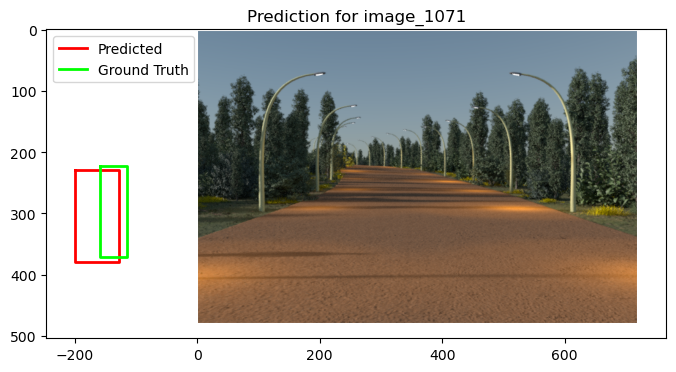

In [22]:
# Example on one validation image
if len(valid_preds) > 0:
    example_id = valid_preds.iloc[14]["id"]
    show_prediction_example(example_id, valid_part, valid_preds, train_df=train_df)